# anomaly. — Model Evaluation Visualizations

Run this notebook from your project root (`anamoly_detection/`), after `evaluate_all_categories.py` has been run at least once (it reads `docs/evaluation_results.json`).

Generates four presentation-ready charts:
1. AUROC by category (sorted, color-coded)
2. Before/after recall — the calibration bug fix story
3. Precision / Recall / F1 across all categories
4. Confusion matrix heatmaps for two representative categories

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Try a couple of likely locations depending on where this notebook lives
candidate_paths = [
    Path("docs/evaluation_results.json"),
    Path("../docs/evaluation_results.json"),
]

RESULTS_PATH = next((p for p in candidate_paths if p.exists()), None)
if RESULTS_PATH is None:
    raise FileNotFoundError(
        "Could not find docs/evaluation_results.json. "
        "Run this notebook from the project root, or adjust RESULTS_PATH manually."
    )

with open(RESULTS_PATH) as f:
    results = json.load(f)

CATEGORY_ORDER = [
    "bottle", "cable", "capsule", "carpet", "grid", "hazelnut",
    "leather", "metal_nut", "pill", "screw", "tile", "toothbrush",
    "transistor", "wood", "zipper",
]
categories = [c for c in CATEGORY_ORDER if c in results and results[c] is not None]
print(f"Loaded results for {len(categories)} categories from {RESULTS_PATH}")

Loaded results for 15 categories from ..\docs\evaluation_results.json


## Chart 1 — AUROC by Category

Sorted from strongest to weakest. Green = near-perfect (structural defects like cracks/breaks), amber/red = genuinely harder categories (subtle textural/print defects) — consistent with published PatchCore benchmarks.

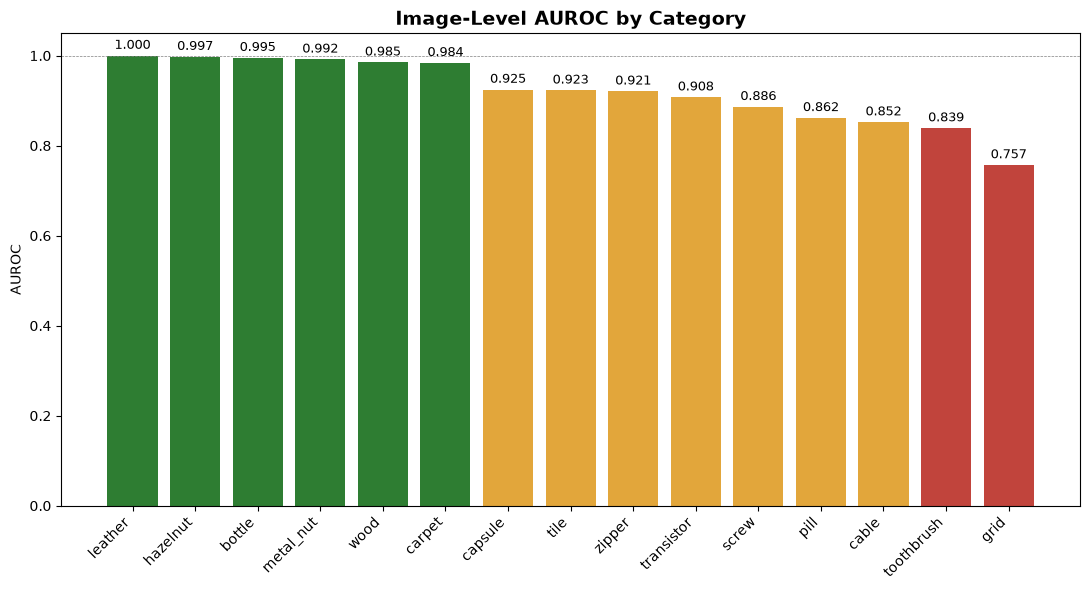

In [2]:
aurocs = {c: results[c]["image_level"]["auroc"] for c in categories}
sorted_cats = sorted(aurocs, key=aurocs.get, reverse=True)
sorted_vals = [aurocs[c] for c in sorted_cats]

def auroc_color(v):
    if v >= 0.95:
        return "#2E7D32"   # green — near-perfect
    elif v >= 0.85:
        return "#E2A63B"   # amber — good
    else:
        return "#C1443C"   # red — genuinely harder

colors = [auroc_color(v) for v in sorted_vals]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(sorted_cats, sorted_vals, color=colors)
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
ax.set_ylabel("AUROC")
ax.set_title("Image-Level AUROC by Category", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")

for bar, v in zip(bars, sorted_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.3f}",
            ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("chart1_auroc_by_category.png", dpi=150)
plt.show()

## Chart 2 — Before / After the Calibration Fix

The headline story: automated thresholds originally used the raw *maximum* good-image score as the "no defect" ceiling, which was extremely sensitive to a single outlier. Recall collapsed for several categories as a result. Switching to a 95th-percentile ceiling recovered recall dramatically.

`BEFORE_FIX_RECALL` below is a fixed snapshot captured during development (before the fix was applied) — it will not regenerate from `evaluation_results.json`, since that file only reflects current, final results.

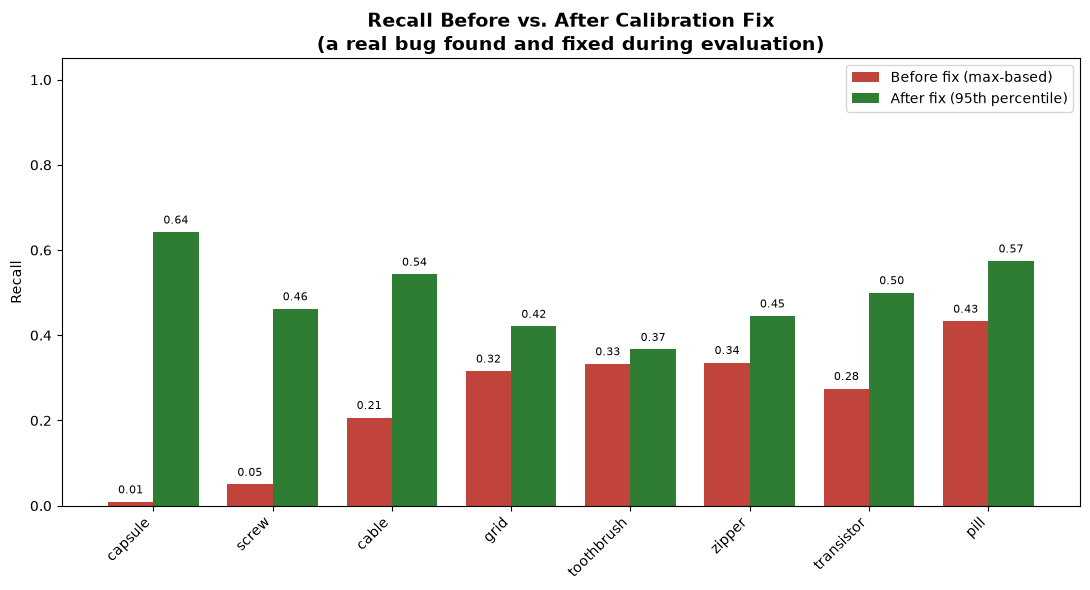

In [3]:
# Snapshot of recall BEFORE the percentile-based calibration fix (max()-based thresholds).
# Only including categories that were meaningfully affected.
BEFORE_FIX_RECALL = {
    "capsule": 0.009,
    "screw": 0.050,
    "cable": 0.207,
    "grid": 0.316,
    "toothbrush": 0.333,
    "zipper": 0.336,
    "transistor": 0.275,
    "pill": 0.433,
}

affected_cats = list(BEFORE_FIX_RECALL.keys())
before_vals = [BEFORE_FIX_RECALL[c] for c in affected_cats]
after_vals = [results[c]["image_level"]["recall"] for c in affected_cats]

x = np.arange(len(affected_cats))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, before_vals, width, label="Before fix (max-based)", color="#C1443C")
ax.bar(x + width/2, after_vals, width, label="After fix (95th percentile)", color="#2E7D32")

ax.set_ylabel("Recall")
ax.set_title("Recall Before vs. After Calibration Fix\n(a real bug found and fixed during evaluation)",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(affected_cats, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    ax.text(i - width/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, a + 0.02, f"{a:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("chart2_before_after_calibration_fix.png", dpi=150)
plt.show()

## Chart 3 — Precision, Recall, F1 Across All Categories

The full-system view, using final (current) results.

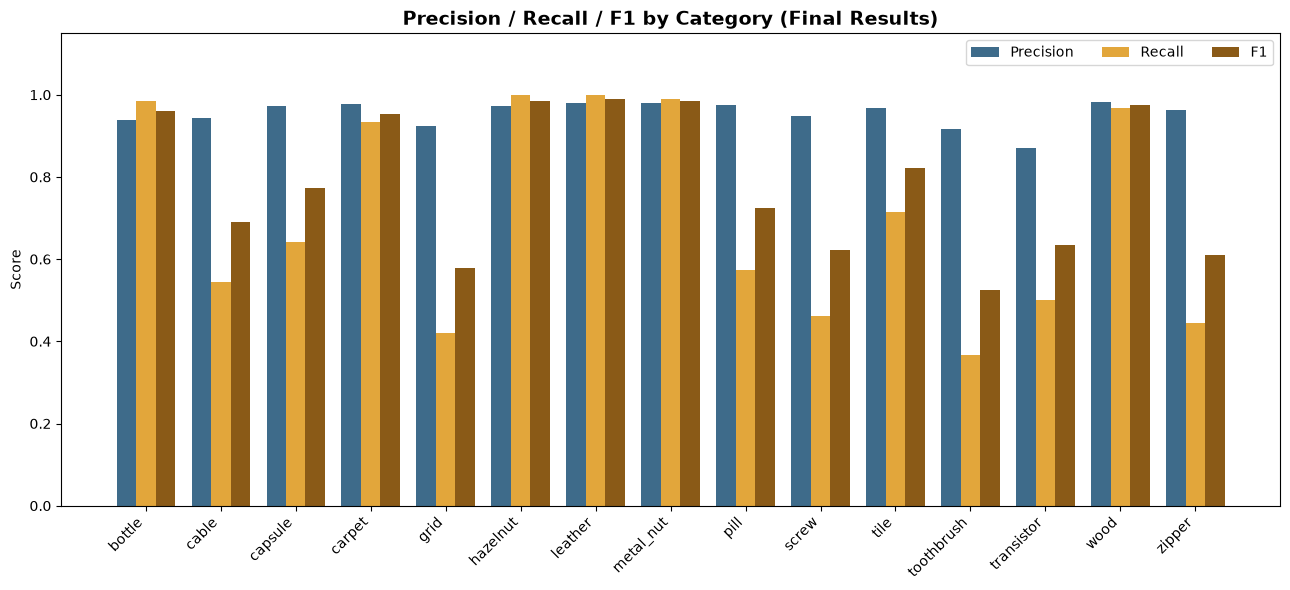

In [4]:
precisions = [results[c]["image_level"]["precision"] for c in categories]
recalls = [results[c]["image_level"]["recall"] for c in categories]
f1s = [results[c]["image_level"]["f1"] for c in categories]

x = np.arange(len(categories))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, precisions, width, label="Precision", color="#3E6B8A")
ax.bar(x, recalls, width, label="Recall", color="#E2A63B")
ax.bar(x + width, f1s, width, label="F1", color="#8A5A17")

ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 by Category (Final Results)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylim(0, 1.15)
ax.legend(loc="upper right", ncol=3)

plt.tight_layout()
plt.savefig("chart3_precision_recall_f1.png", dpi=150)
plt.show()

## Chart 4 — Confusion Matrices (Two Representative Categories)

One near-perfect category (`bottle`) and one genuinely harder category (`capsule`), side by side.

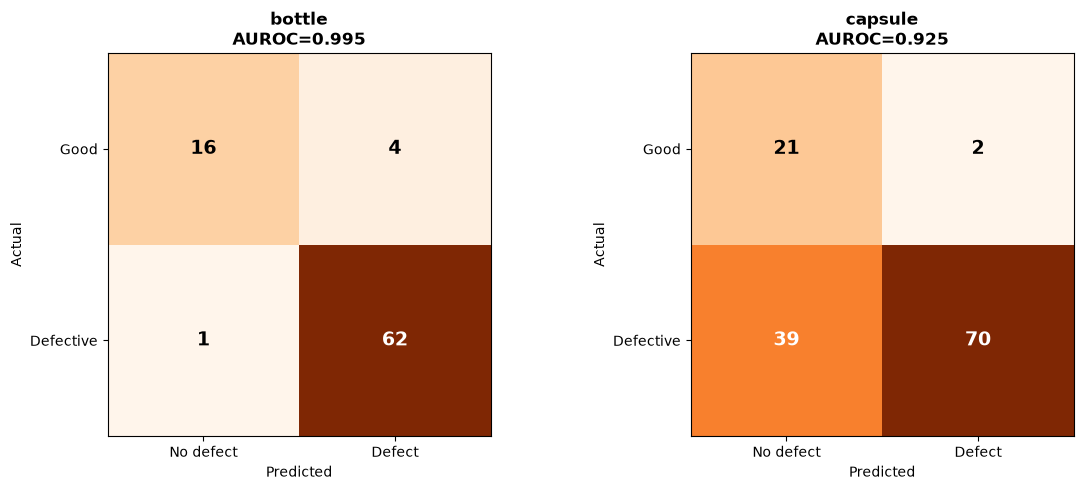

In [5]:
def confusion_matrix_array(cat):
    m = results[cat]["image_level"]
    # rows: actual [good, defective], cols: predicted [no defect, defect]
    return np.array([
        [m["true_negatives"], m["false_positives"]],
        [m["false_negatives"], m["true_positives"]],
    ])

compare_cats = [c for c in ["bottle", "capsule"] if c in categories]

fig, axes = plt.subplots(1, len(compare_cats), figsize=(6 * len(compare_cats), 5))
if len(compare_cats) == 1:
    axes = [axes]

labels = ["No defect", "Defect"]

for ax, cat in zip(axes, compare_cats):
    cm = confusion_matrix_array(cat)
    im = ax.imshow(cm, cmap="Oranges")
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Good", "Defective"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{cat}\nAUROC={results[cat]['image_level']['auroc']:.3f}", fontweight="bold")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("chart4_confusion_matrices.png", dpi=150)
plt.show()

## Summary Stats 


In [6]:
avg_auroc = np.mean([results[c]["image_level"]["auroc"] for c in categories])
avg_recall = np.mean([results[c]["image_level"]["recall"] for c in categories])
avg_precision = np.mean([results[c]["image_level"]["precision"] for c in categories])
best_cat = max(categories, key=lambda c: results[c]["image_level"]["auroc"])
worst_cat = min(categories, key=lambda c: results[c]["image_level"]["auroc"])

print(f"Categories evaluated: {len(categories)}")
print(f"Average AUROC: {avg_auroc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")
print(f"Average Recall: {avg_recall:.3f}")
print(f"Best category: {best_cat} (AUROC {results[best_cat]['image_level']['auroc']:.3f})")
print(f"Hardest category: {worst_cat} (AUROC {results[worst_cat]['image_level']['auroc']:.3f})")

Categories evaluated: 15
Average AUROC: 0.922
Average Precision: 0.954
Average Recall: 0.703
Best category: leather (AUROC 1.000)
Hardest category: grid (AUROC 0.757)
